In [9]:
import matplotlib.pyplot as plt
from utils import ResultLoader, load_plot, load_plot_all_runs

# 设置绘图风格
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'figure.titlesize': 18
})

In [10]:
# --- 实验参数配置 ---
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "num_clients": 10,
    "alpha": 0.1,
    "epochs": 1,
    "batch_size": 64,
    "lr": 0.01,
    "adj_type": "ring",
}

In [19]:
# 初始化加载器，指向 Ray 实验结果目录
loader = ResultLoader("../results_ray")

# 定义去中心化/点对点算法实验组
experiments = {
    # --- 基准对照 ---
    "Local": ("local", {}),
    "FedProto": ("fedproto", {"mu": 0.1}),

    # --- DFedUP 变体 ---
    **{("DFedUP" + (str(i) if i > 0 else "")): (f"dfedup{i}" if i > 0 else "dfedup", {"mu": 1.0}) for i in range(100)},


    # --- 其他去中心化基准算法 ---
    "L2C": ("l2c", {"val_ratio": 0.1, "lr_alpha": 0.1, "prune_round": 20, "prune_num": 0}),
    "DisPFL": ("dispfl", {"dense_ratio": 0.5, "anneal_factor": 1.0}),
    "PearFL": ("pearfl", {"lamda": 0.1}),
    "DFedAvgM": ("dfedavgm", {}),
    "DFedPGP": ("dfedpgp", {"local_v_epochs": 1, "lr_v": 0.01, "momentum_v": 0.0, "weight_decay_v": 0.0}),
    "ProxyFL": ("proxyfl", {"mu": 0.01})
}

# 快捷选择组
dfedup_family = [f"DFedUP{i}" if i > 0 else "DFedUP" for i in range(13)]
baselines = ["Local", "FedProto", "L2C", "DisPFL", "PearFL", "DFedAvgM", "DFedPGP", "ProxyFL"]

In [12]:
load_plot(baselines, experiments, common_args, loader, x_lim=100, do_plot=False)

Summary of ACC:
--------------------------------------------------------------------------------
Algorithm            |    Model Max | Model Last10 |    Proto Max | Proto Last10
--------------------------------------------------------------------------------
Local                |      83.1838 |      82.0023 |       0.0000 |       0.0000
FedProto             |      83.8569 |      82.9003 |      82.8463 |      82.1438
L2C                  |      83.7460 |      82.7973 |       0.0000 |       0.0000
DisPFL               |      83.8420 |      82.4751 |       0.0000 |       0.0000
PearFL               |      62.1708 |      60.6657 |       0.0000 |       0.0000
DFedAvgM             |      62.6340 |      61.0734 |       0.0000 |       0.0000
DFedPGP              |      86.1931 |      85.5213 |       0.0000 |       0.0000
ProxyFL              |      83.3489 |      82.2323 |       0.0000 |       0.0000
--------------------------------------------------------------------------------


In [22]:
# 2. 统计多轮实验均值与方差
load_plot_all_runs(
    dfedup_family,
    experiments,
    common_args,
    loader,
    x_lim=200
)

Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------
DFedUP                    |  85.9838 ± 0.0000  |  84.8518 ± 0.0000  (1 runs)
DFedUP1                   |  86.5928 ± 0.0000  |  85.5321 ± 0.0000  (1 runs)
DFedUP2                   |  85.6892 ± 0.0000  |  84.5546 ± 0.0000  (1 runs)
DFedUP3                   |  83.8970 ± 0.0000  |  83.6098 ± 0.0000  (1 runs)
DFedUP4                   |  83.8963 ± 0.0000  |  83.8013 ± 0.0000  (1 runs)
DFedUP5-Model             |  84.3424 ± 0.0000  |  83.4150 ± 0.0000  (1 runs)
DFedUP5-Proto             |  83.7796 ± 0.0000  |  82.8092 ± 0.0000  (1 runs)
DFedUP6                   |  84.0101 ± 0.0000  |  83.8534 ± 0.0000  (1 runs)
DFedUP7                   |  83.6223 ± 0.0000  |  83.3561 ± 0.0000  (1 runs)
DFedUP8-Model             |  84.6396 ± 0.0000  | 

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png
Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
DFedUP               |         84.6730 |         82.6985
DFedUP1              |         84.2018 |         83.0233
DFedUP5-Model        |         80.2279 |         78.8402
DFedUP5-Proto        |         82.6465 |         80.5396
DFedUP8-Model        |         82.3354 |         79.6367
DFedUP8-Proto        |         75.9209 |         71.6680
DFedUP9-Model        |         81.7910 |         80.5950
DFedUP9-Proto        |         59.0324 |         57.5504
DFedUP10             |         83.6291 |         82.6912
PearFL               |         55.2103 |         52.4797
FedProto-Model       |         81.8601 |         78.8444
FedProto-Proto       |         80.7687 |         78.9379
------------------------------------------------

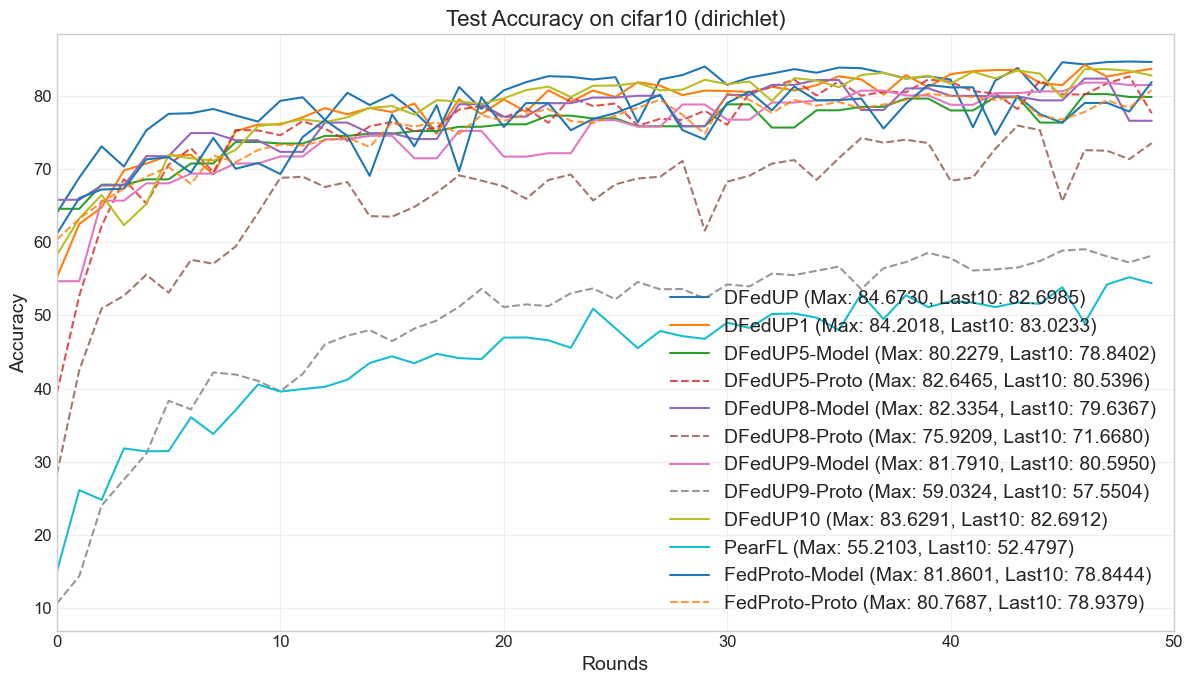

In [21]:
load_plot(
    # ["DFedUP", "DFedUP1", "DFedUP2", "DFedUP3", "DFedUP4", "DFedUP5", "DFedUP6", "DFedUP7", "PearFL", "FedProto"],
    ["DFedUP", "DFedUP1", "DFedUP5", "DFedUP8", "DFedUP9", "DFedUP10", "PearFL", "FedProto"],
    experiments,
    common_args,
    loader,
    x_lim=50
)